In [2]:
from cogent3.maths.matrix_exponential_integration import expected_number_subs
import matplotlib.pyplot as plt
import paths
import pandas as pd

import pickle

import re

In [3]:
#function to parse the alignment lenght

def parse_alignment_length(s: str, fmt: str = "{:.6e}") -> str:
    """
    Parse strings like "alignment length: X" and return X formatted in scientific notation.

    Parameters
    - s: input string containing a token like "alignment length: 12345"
    - fmt: a format string compatible with float.format, default "{:.6e}" (6 decimals in exp notation)

    Returns
    - str: the parsed number formatted according to `fmt` (scientific notation by default)

    Raises ValueError if the token is not found.
    """
    m = re.search(r'alignment\s*length\s*:\s*([0-9]+(?:\.[0-9]+)?)', s, re.I)
    if not m:
        raise ValueError(f"Can't parse alignment length from: {s!r}")
    token = m.group(1)
    # normalize to float for consistent formatting
    value = float(token)
    return fmt.format(value)

## Intergenic Ancestral Repeats (IGAR)

In [4]:
region = "intergenicAR/chrm22/sm_output/"
folder_in = paths.DATA_HUMCHIMPORANG115 + region
file_in = folder_in + "singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_IGAR=pickle.load(infile)

file_in = folder_in + "singlent_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

IGAR_motif_probs = result_IGAR.lf.get_param_value("mprobs")
humanQ_IGAR = result_IGAR.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_IGAR = expected_number_subs(IGAR_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS IGAR: ")
print(humanENS_IGAR)

result_IGAR.lf

alignment lenght  2.436380e+05
Human ENS IGAR: 
0.41488117259352075


GN
log-likelihood = -979466.4840
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Orangutan     root          NA      NA      NA      NA      NA      NA
Human         root        0.41    0.78    0.64    0.96    0.71    0.49
Chimpanzee    root        0.59    1.17    0.83    1.34    1.01    0.83
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
  NA      NA      NA      NA      NA      NA
0.83    0.98    0.60    0.67    0.77    0.57
1.27    1.18    0.83    0.72    1.34    1.00
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.26    0.24    0.24    0.26
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.45
T        C           0.19
T        A           0.20
T        G           0.17
C        T           0.21
C        C           0.43
C        A           0.17
C        G           0.19
A        T           0.19
A        C           0.18
A        A           0.46
A        G           0.17
G        T           0.18
G        C           0.19
G        A           0.19
G        G           0.43
-------------------------

## CDS

In [5]:
region = "cds/chrm22/sm_output/"
folder_in = paths.DATA_HUMCHIMPORANG115 + region
file_in = folder_in + "singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_cds=pickle.load(infile)

file_in = folder_in + "singlent_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

cds_motif_probs = result_cds.lf.get_param_value("mprobs")
humanQ_cds = result_cds.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_cds = expected_number_subs(cds_motif_probs, humanQ_cds, t=1.0)
#This is the ENS of cdss if selection was the same as on IGAR. Instead of using the cds Q matrix humanQ_cds, I use the IGAR Q humanQ_IGAR
humanENS_cds_IGARQ = expected_number_subs(cds_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS cds: ")
print(humanENS_cds)
print("Human ENS cds with IGAR Q: ")
print(humanENS_cds_IGARQ)

result_cds.lf

alignment lenght  5.387630e+05
Human ENS cds: 
0.004102694468921054
Human ENS cds with IGAR Q: 
0.41165784409384054


GN
log-likelihood = -837924.1355
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Chimpanzee    root        0.01    1.15    1.99    0.86    0.90    1.21
Human         root        0.00    1.13    4.59    0.62    1.44    1.58
Orangutan     root          NA      NA      NA      NA      NA      NA
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
2.70    2.38    1.57    0.98    0.75    2.19
7.94    6.68    1.45    1.24    0.69    3.49
  NA      NA      NA      NA      NA      NA
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.22    0.30    0.29    0.19
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.98
T        C           0.02
T        A           0.00
T        G           0.00
C        T           0.01
C        C           0.98
C        A           0.00
C        G           0.00
A        T           0.00
A        C           0.00
A        A           0.98
A        G           0.01
G        T           0.00
G        C           0.00
G        A           0.01
G        G           0.98
-------------------------

## Introns

In [7]:
region = "introns_nonUTR/chrm22/sm_output/"
folder_in = paths.DATA_HUMCHIMPORANG115 + region
file_in = folder_in + "singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_introns=pickle.load(infile)

file_in = folder_in + "singlent_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

intron_motif_probs = result_introns.lf.get_param_value("mprobs")
humanQ_introns = result_introns.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_introns = expected_number_subs(intron_motif_probs, humanQ_introns, t=1.0)
#This is the ENS of introns if selection was the same as on IGAR. Instead of using the introns Q matrix humanQ_introns, I use the IGAR Q humanQ_IGAR
humanENS_introns_IGARQ = expected_number_subs(intron_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS introns: ")
print(humanENS_introns)
print("Human ENS introns with IGAR Q: ")
print(humanENS_introns_IGARQ)

result_introns.lf


alignment lenght  2.636300e+04
Human ENS introns: 
0.20103115002094582
Human ENS introns with IGAR Q: 
0.41373998532340733


GN
log-likelihood = -94578.9756
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Human         root        0.20    1.04    1.06    0.75    0.86    0.71
Orangutan     root          NA      NA      NA      NA      NA      NA
Chimpanzee    root        0.19    1.27    1.38    1.35    1.18    1.15
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
0.77    0.81    0.87    0.77    0.87    0.81
  NA      NA      NA      NA      NA      NA
1.31    1.01    1.11    1.03    1.52    1.50
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.24    0.26    0.26    0.24
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.49
T        C           0.17
T        A           0.18
T        G           0.16
C        T           0.17
C        C           0.52
C        A           0.14
C        G           0.17
A        T           0.18
A        C           0.16
A        A           0.50
A        G           0.17
G        T           0.15
G        C           0.16
G        A           0.16
G        G           0.54
-------------------------

## 5' UTR

In [8]:
region = "introns5UTR/chrm22/sm_output/"
folder_in = paths.DATA_HUMCHIMPORANG115 + region
file_in = folder_in + "singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_5UTR=pickle.load(infile)

file_in = folder_in + "singlent_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

intron_motif_probs = result_5UTR.lf.get_param_value("mprobs")
humanQ_5UTR = result_5UTR.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_5UTR = expected_number_subs(intron_motif_probs, humanQ_5UTR, t=1.0)
#This is the ENS of 5UTR if selection was the same as on IGAR. Instead of using the 5UTR Q matrix humanQ_5UTR, I use the IGAR Q humanQ_IGAR
humanENS_5UTR_IGARQ = expected_number_subs(intron_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS 5UTR: ")
print(humanENS_5UTR)
print("Human ENS 5UTR with IGAR Q: ")
print(humanENS_5UTR_IGARQ)

result_5UTR.lf

alignment lenght  2.278600e+04
Human ENS 5UTR: 
0.12376828440231984
Human ENS 5UTR with IGAR Q: 
0.4140387696266733


GN
log-likelihood = -73664.0634
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Human         root        0.12    0.80    1.28    1.08    0.99    1.04
Orangutan     root          NA      NA      NA      NA      NA      NA
Chimpanzee    root        0.15    0.93    1.10    0.92    0.86    0.89
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
1.18    1.12    1.14    0.78    1.15    0.93
  NA      NA      NA      NA      NA      NA
1.14    0.81    0.81    1.08    1.12    1.02
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.24    0.25    0.26    0.24
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.66
T        C           0.12
T        A           0.11
T        G           0.11
C        T           0.11
C        C           0.66
C        A           0.11
C        G           0.13
A        T           0.10
A        C           0.11
A        A           0.66
A        G           0.12
G        T           0.11
G        C           0.12
G        A           0.12
G        G           0.66
-------------------------

## 3' UTR

In [9]:
region = "introns3UTR/chrm22/sm_output/"
folder_in = paths.DATA_HUMCHIMPORANG115 + region
file_in = folder_in + "singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_3UTR=pickle.load(infile)

file_in = folder_in + "singlent_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

intron_motif_probs = result_3UTR.lf.get_param_value("mprobs")
humanQ_3UTR = result_3UTR.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_3UTR = expected_number_subs(intron_motif_probs, humanQ_3UTR, t=1.0)
#This is the ENS of 3UTR if selection was the same as on IGAR. Instead of using the 3UTR Q matrix humanQ_3UTR, I use the IGAR Q humanQ_IGAR
humanENS_3UTR_IGARQ = expected_number_subs(intron_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS 3UTR: ")
print(humanENS_3UTR)
print("Human ENS 3UTR with IGAR Q: ")
print(humanENS_3UTR_IGARQ)

result_3UTR.lf

alignment lenght  1.403800e+04
Human ENS 3UTR: 
0.16972877316846852
Human ENS 3UTR with IGAR Q: 
0.41300232641634904


GN
log-likelihood = -50686.2631
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Human         root        0.17    0.94    1.03    0.47    0.63    0.66
Orangutan     root          NA      NA      NA      NA      NA      NA
Chimpanzee    root        0.23    1.13    1.33    1.31    1.13    1.45
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
0.47    0.74    0.91    0.68    0.50    0.72
  NA      NA      NA      NA      NA      NA
1.32    1.31    1.23    0.89    1.53    1.55
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.23    0.27    0.27    0.23
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.50
T        C           0.18
T        A           0.15
T        G           0.16
C        T           0.16
C        C           0.49
C        A           0.15
C        G           0.19
A        T           0.15
A        C           0.16
A        A           0.52
A        G           0.17
G        T           0.16
G        C           0.20
G        A           0.16
G        G           0.49
-------------------------

## Introns Ancestral Repeats (IntronAR)

In [10]:
region = "intronsAR/chrm22/sm_output/"
folder_in = paths.DATA_HUMCHIMPORANG115 + region
file_in = folder_in + "singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_intronsAR=pickle.load(infile)

file_in = folder_in + "singlent_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

intronsAR_motif_probs = result_intronsAR.lf.get_param_value("mprobs")
humanQ_intronsAR = result_intronsAR.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_intronsAR = expected_number_subs(intronsAR_motif_probs, humanQ_intronsAR, t=1.0)
#This is the ENS of intronsAR if selection was the same as on IGAR. Instead of using the intronsAR Q matrix humanQ_intronsAR, I use the IGAR Q humanQ_IGAR
humanENS_intronsAR_IGARQ = expected_number_subs(intronsAR_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS intronsAR: ")
print(humanENS_intronsAR)
print("Human ENS intronsAR with IGAR Q: ")
print(humanENS_intronsAR_IGARQ)

#print("Motif probs: ")
#print(intronsAR_motif_probs)

result_intronsAR.lf

alignment lenght  1.802980e+05
Human ENS intronsAR: 
0.3401367020522965
Human ENS intronsAR with IGAR Q: 
0.4137612160628405


GN
log-likelihood = -692108.7365
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Orangutan     root          NA      NA      NA      NA      NA      NA
Human         root        0.34    0.95    1.04    0.76    0.71    0.87
Chimpanzee    root        0.28    1.03    1.12    1.17    1.06    1.06
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
  NA      NA      NA      NA      NA      NA
0.67    0.67    0.80    0.67    0.93    0.94
1.13    1.06    1.04    0.78    1.17    1.09
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.24    0.26    0.27    0.23
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.46
T        C           0.19
T        A           0.18
T        G           0.17
C        T           0.19
C        C           0.46
C        A           0.17
C        G           0.18
A        T           0.20
A        C           0.17
A        A           0.46
A        G           0.18
G        T           0.16
G        C           0.18
G        A           0.18
G        G           0.48
-------------------------

## Intergenic distal (5kb distal from transcript)

In [11]:
region = "distalIG/chrm22/sm_output/"
folder_in = paths.DATA_HUMCHIMPORANG115 + region
file_in = folder_in + "singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_distalIG=pickle.load(infile)

file_in = folder_in + "singlent_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

distalIG_motif_probs = result_distalIG.lf.get_param_value("mprobs")
humanQ_distalIG = result_distalIG.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_distalIG = expected_number_subs(distalIG_motif_probs, humanQ_distalIG, t=1.0)
humanENS_distalIG_IGARQ = expected_number_subs(distalIG_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS distalIG: ")
print(humanENS_distalIG)
print("Human ENS distalIG with IGAR Q: ")
print(humanENS_distalIG_IGARQ)

result_distalIG.lf

alignment lenght  5.036700e+04
Human ENS distalIG: 
0.3328203519661795
Human ENS distalIG with IGAR Q: 
0.41334520869765534


GN
log-likelihood = -186553.1346
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Orangutan     root          NA      NA      NA      NA      NA      NA
Human         root        0.33    0.71    1.27    0.59    0.69    0.74
Chimpanzee    root        0.30    1.12    0.90    0.87    0.83    1.02
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
  NA      NA      NA      NA      NA      NA
0.88    0.97    0.77    0.99    0.93    0.94
0.91    0.88    0.92    0.91    1.12    1.01
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.24    0.26    0.28    0.22
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.60
T        C           0.15
T        A           0.10
T        G           0.15
C        T           0.11
C        C           0.63
C        A           0.13
C        G           0.13
A        T           0.10
A        C           0.14
A        A           0.61
A        G           0.16
G        T           0.10
G        C           0.15
G        A           0.13
G        G           0.61
-------------------------

## Intergenic proximal 5' (5kb proximal from transcript start)

In [12]:
region = "proximal5IG/chrm22/sm_output/"
folder_in = paths.DATA_HUMCHIMPORANG115 + region
file_in = folder_in + "singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_proximal5IG=pickle.load(infile)

file_in = folder_in + "singlent_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

proximal5IG_motif_probs = result_proximal5IG.lf.get_param_value("mprobs")
humanQ_proximal5IG = result_proximal5IG.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_proximal5IG = expected_number_subs(proximal5IG_motif_probs, humanQ_proximal5IG, t=1.0)
humanENS_proximal5IG_IGARQ = expected_number_subs(proximal5IG_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS proximal5IG: ")
print(humanENS_proximal5IG)
print("Human ENS proximal5IG with IGAR Q: ")
print(humanENS_proximal5IG_IGARQ)

result_proximal5IG.lf

alignment lenght  3.760200e+04
Human ENS proximal5IG: 
0.2558831485678207
Human ENS proximal5IG with IGAR Q: 
0.4125236592247407


GN
log-likelihood = -131545.8540
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Orangutan     root          NA      NA      NA      NA      NA      NA
Human         root        0.26    0.98    1.12    0.55    0.64    1.03
Chimpanzee    root        0.12    1.15    2.82    1.63    1.57    0.76
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
  NA      NA      NA      NA      NA      NA
0.82    0.72    1.03    0.68    0.43    1.03
0.96    1.16    1.20    1.73    1.30    2.25
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.22    0.28    0.29    0.22
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.57
T        C           0.17
T        A           0.11
T        G           0.15
C        T           0.14
C        C           0.57
C        A           0.12
C        G           0.16
A        T           0.13
A        C           0.15
A        A           0.55
A        G           0.17
G        T           0.11
G        C           0.17
G        A           0.15
G        G           0.57
-------------------------

## Intergenic proximal 3' (5kb proximal from transcript end)

In [13]:
region = "proximal3IG/chrm22/sm_output/"
folder_in = paths.DATA_HUMCHIMPORANG115 + region
file_in = folder_in + "singlent_lh.pickle"
with open(file_in, mode = "rb") as infile: 
    result_proximal3IG=pickle.load(infile)

file_in = folder_in + "singlent_alnstat.txt"
with open(file_in, "r") as f:
    content = f.read().strip()
print("alignment lenght ", parse_alignment_length(content))

proximal3IG_motif_probs = result_proximal3IG.lf.get_param_value("mprobs")
humanQ_proximal3IG = result_proximal3IG.lf.get_rate_matrix_for_edge("Human", calibrated=False)
humanENS_proximal3IG = expected_number_subs(proximal3IG_motif_probs, humanQ_proximal3IG, t=1.0)
humanENS_proximal3IG_IGARQ = expected_number_subs(proximal3IG_motif_probs, humanQ_IGAR, t=1.0)

print("Human ENS proximal3IG: ")
print(humanENS_proximal3IG)
print("Human ENS proximal3IG with IGAR Q: ")
print(humanENS_proximal3IG_IGARQ)

result_proximal3IG.lf

alignment lenght  1.845900e+04
Human ENS proximal3IG: 
0.28208594089010813
Human ENS proximal3IG with IGAR Q: 
0.4126859132875128


GN
log-likelihood = -68786.0287
number of free parameters = 36
======================================================================
edge          parent    length     A>C     A>G     A>T     C>A     C>G
----------------------------------------------------------------------
Human         root        0.28    1.36    1.03    0.59    0.67    0.85
Orangutan     root          NA      NA      NA      NA      NA      NA
Chimpanzee    root        0.34    1.70    3.28    1.79    1.14    1.64
----------------------------------------------------------------------

continued: 
============================================
 C>T     G>A     G>C     G>T     T>A     T>C
--------------------------------------------
0.42    0.85    0.36    0.81    0.26    0.86
  NA      NA      NA      NA      NA      NA
1.45    2.19    1.57    1.28    1.83    2.13
--------------------------------------------

============================
   A       C       G       T
----------------------------
0.22    0.28    0.28    0.22
----------------------------
=========================
motif    motif2    dpsubs
-------------------------
T        T           0.58
T        C           0.14
T        A           0.15
T        G           0.12
C        T           0.13
C        C           0.59
C        A           0.14
C        G           0.15
A        T           0.13
A        C           0.13
A        A           0.57
A        G           0.17
G        T           0.16
G        C           0.16
G        A           0.12
G        G           0.57
-------------------------

Text(0, 0.5, 'Constraint')

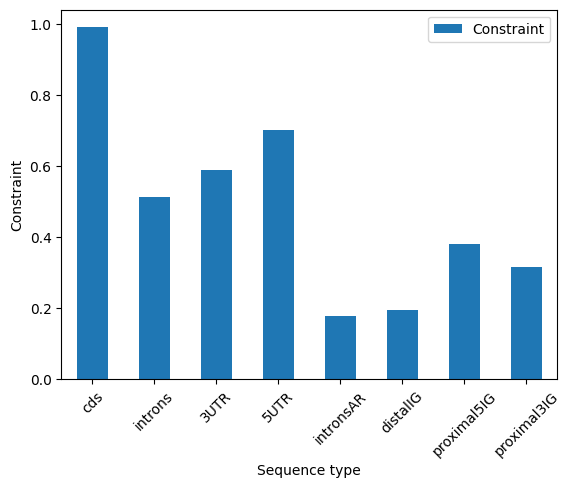

In [17]:
Constraint_data = pd.DataFrame([
    ['cds', (humanENS_cds_IGARQ - humanENS_cds)/humanENS_cds_IGARQ],
    ['introns', (humanENS_introns_IGARQ - humanENS_introns)/humanENS_introns_IGARQ],
    ['3UTR', (humanENS_3UTR_IGARQ - humanENS_3UTR)/humanENS_3UTR_IGARQ],
    ['5UTR', (humanENS_5UTR_IGARQ - humanENS_5UTR)/humanENS_5UTR_IGARQ],
    ['intronsAR', (humanENS_intronsAR_IGARQ - humanENS_intronsAR)/humanENS_intronsAR_IGARQ],
    ['distalIG', (humanENS_distalIG_IGARQ - humanENS_distalIG)/humanENS_distalIG_IGARQ],
    ['proximal5IG', (humanENS_proximal5IG_IGARQ - humanENS_proximal5IG)/humanENS_proximal5IG_IGARQ],
    ['proximal3IG', (humanENS_proximal3IG_IGARQ - humanENS_proximal3IG)/humanENS_proximal3IG_IGARQ]
    ],
    columns = ['Sequence type', 'Constraint'])


Constraint_data.plot(
    x='Sequence type',
    kind = 'bar',
    rot=45)
plt.ylabel('Constraint')

In [18]:
Constraint_data.to_csv("Output_data/Constraint_perregion.csv", index=False)
Constraint_data

,Sequence type,Constraint
0,cds,0.990034
1,introns,0.514112
2,3UTR,0.589037
3,5UTR,0.701071
4,intronsAR,0.177940
5,distalIG,0.194813
6,proximal5IG,0.379713
7,proximal3IG,0.316463


In [16]:
Every chromosome independently

SyntaxError: invalid syntax (3757979378.py, line 1)